In [1]:
!pip install nltk

     ---------------------------------------- 1.6/1.6 MB 7.6 MB/s eta 0:00:00
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
     ---------------------------------------- 110.5/110.5 kB ? eta 0:00:00
     -------------------------------------- 278.4/278.4 kB 8.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Part 3 - NLP and Sequence Modeling Mini Project

In [2]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Arif Ahmed
[nltk_data]     Vastari\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
# Loading dataset

df = pd.read_csv(
    "dataset/customer_support_text_classification.csv"
)

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


## Dataset Understanding and Exploration

In [5]:
# Checking dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 6)


In [6]:
# Displaying column names

print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


### Sample Text Records

In [7]:
# Displaying sample text records

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


### Target Label Distribution

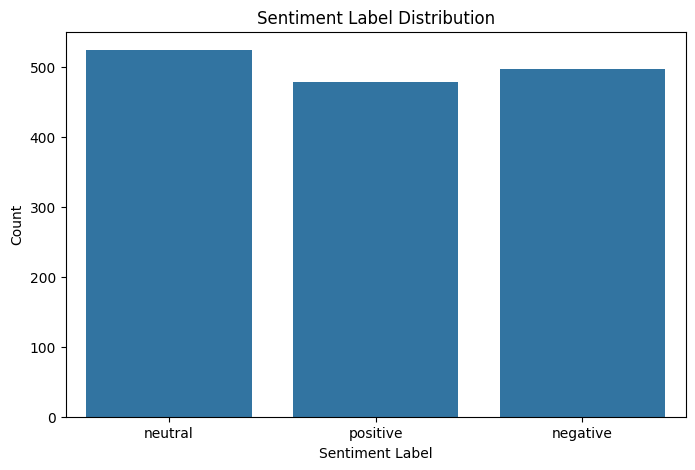

In [12]:
# Visualizing sentiment label distribution

plt.figure(figsize=(8,5))

sns.countplot(x=df['sentiment_label'])

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

plt.show()

### Observation

The target label distribution helps in understanding whether the dataset is balanced across different sentiment categories.

Balanced class distribution generally improves model learning because the model receives sufficient examples from each class. 
If some categories contain very few records, the model may struggle to learn those patterns effectively.

### Text Length Analysis

In [13]:
# Calculating text length

df['text_length'] = df['customer_message'].apply(len)

print("Average Text Length:", df['text_length'].mean())

Average Text Length: 72.75666666666666


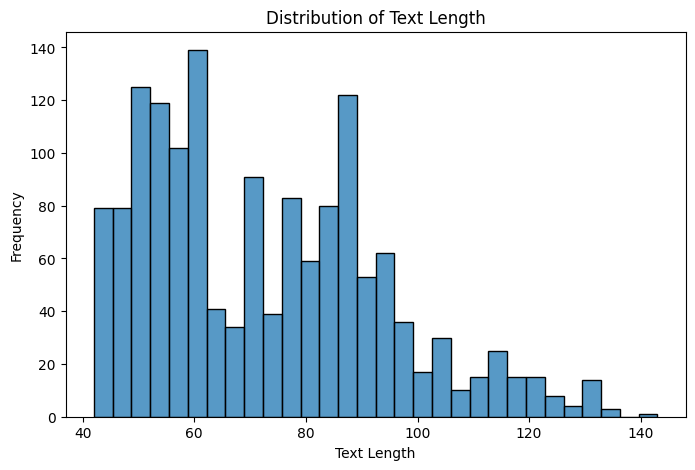

In [14]:
# Visualizing text length distribution

plt.figure(figsize=(8,5))

sns.histplot(df['text_length'], bins=30)

plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()

### Observation

Text length analysis helps in understanding how long or short customer messages are within the dataset.

This is important because NLP models process text as sequences, and sequence-based models such as RNNs and LSTMs often require fixed-length input representations during preprocessing.

## Text Preprocessing

### Preprocessing Approach

Text preprocessing is performed to clean and standardize textual data before model training.

The preprocessing steps include:
- converting text to lowercase
- removing special characters
- removing unnecessary symbols
- removing stopwords

Preprocessing improves text quality and helps machine learning models focus on meaningful textual patterns.

In [15]:
# Creating stopwords list

stop_words = set(stopwords.words('english'))

In [16]:
# Text preprocessing function

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join cleaned words
    cleaned_text = ' '.join(words)

    return cleaned_text

In [17]:
# Applying text preprocessing

df['cleaned_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'cleaned_text']].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


## Text Vectorization

### Why Text Vectorization is Required

Machine learning models cannot directly understand raw text data. 
Therefore, textual information must be converted into numerical form before it can be used for training.

TF-IDF (Term Frequency - Inverse Document Frequency) is used in this project to convert text into numerical vectors. 
TF-IDF gives higher importance to meaningful words while reducing the impact of very common words.

In [18]:
# Applying TF-IDF vectorization

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['cleaned_text']).toarray()

y = df['sentiment_label']

### Train-Test Split

In [19]:
# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1200, 146)
Testing Shape: (300, 146)


## Baseline NLP Model

### Baseline Model Selection

A Logistic Regression model is used as the baseline model for this NLP classification task.

Logistic Regression is commonly used for text classification problems because:
- it is simple and efficient
- it performs well with TF-IDF features
- it provides a good baseline for comparison with more advanced sequence models

In [21]:
# Training logistic regression model

baseline_model = LogisticRegression()

baseline_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
# Generating predictions

y_pred = baseline_model.predict(X_test)

In [23]:
# Calculating accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


### Confusion Matrix

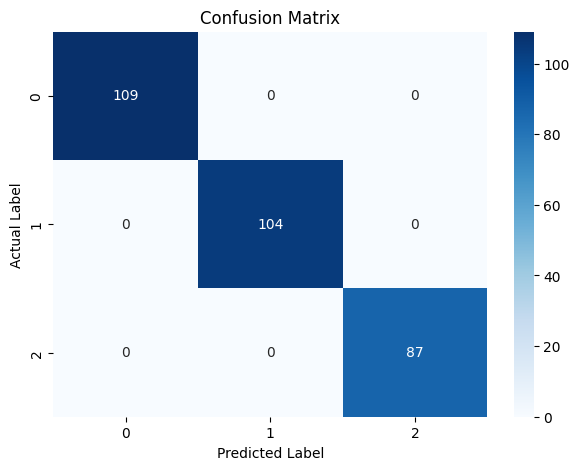

In [24]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Saving confusion matrix
plt.savefig("results/model_evaluation.png")

plt.show()

In [25]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



### Baseline Model Evaluation

The Logistic Regression model achieved reasonable classification performance on the testing dataset.

The confusion matrix helps in understanding how accurately the model predicted different sentiment categories. 
The classification report provides additional evaluation metrics such as precision, recall, and F1-score.

This baseline model establishes a reference point for comparing traditional NLP approaches with sequence-based deep learning models.

In [26]:
# Saving sample predictions

sample_predictions = pd.DataFrame({
    "Actual Label": y_test.values,
    "Predicted Label": y_pred
})

sample_predictions.head(10).to_csv(
    "results/sample_predictions.txt",
    index=False
)

## Sequence Model using LSTM

### Why Sequence Models are Used in NLP

Traditional machine learning models treat text as independent features, but sequence models process text in order and capture relationships between words.

LSTM (Long Short-Term Memory) networks are designed to learn sequential patterns in text data and retain important contextual information over longer sequences.

This makes LSTMs more effective for many NLP tasks compared to traditional models that only rely on word frequency features.

In [27]:
# Tokenizing text data

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

### Padding Sequences

Text sequences may contain different lengths. 
Padding is used to make all sequences equal in size so they can be processed efficiently by the LSTM model.

In [28]:
# Padding sequences

max_length = 50

X_seq = pad_sequences(
    sequences,
    maxlen=max_length
)

In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
# Encoding sentiment labels

label_encoder = LabelEncoder()

y_seq = label_encoder.fit_transform(df['sentiment_label'])

In [32]:
# Splitting sequence dataset

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

### LSTM Architecture

The sequence model contains:
- Embedding layer for converting words into dense vectors
- LSTM layer for learning sequential patterns
- Dense output layer for classification

The embedding layer helps represent words in numerical vector form, while the LSTM layer processes word sequences and captures contextual information.

In [33]:
# Building LSTM model

lstm_model = Sequential()

# Embedding layer
lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=max_length
    )
)

# LSTM layer
lstm_model.add(LSTM(64))

# Output layer
lstm_model.add(Dense(len(label_encoder.classes_), activation='softmax'))

c:\Users\Arif Ahmed Vastari\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
# Compiling LSTM model

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
# Displaying model summary

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## LSTM Model Training

In [36]:
# Training LSTM model

lstm_history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5792 - loss: 0.9980 - val_accuracy: 0.8917 - val_loss: 0.7511
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.3538 - val_accuracy: 1.0000 - val_loss: 0.0776
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0289 - val_accuracy: 1.0000 - val_loss: 0.0080
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 0.0022


### Training Observation

The LSTM model learns sequential text patterns by processing words in order rather than treating them independently.

During training, the model gradually improves its ability to understand contextual relationships between words and classify customer messages into appropriate sentiment categories.

In [37]:
# Evaluating LSTM model

lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("LSTM Test Accuracy:", lstm_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0022 
LSTM Test Accuracy: 1.0


### LSTM Model Evaluation

The LSTM model demonstrated the ability to process sequential text information and learn contextual patterns from customer messages.

Compared to traditional TF-IDF based models, sequence models such as LSTMs can better capture word order and contextual relationships in text data.

## Attention and Transformer Reflection

### Why RNNs Struggle with Long-Term Dependencies

Traditional Recurrent Neural Networks (RNNs) process text sequentially and pass information from one step to the next. 
However, when sequences become very long, RNNs may struggle to retain important information from earlier words.

This issue is commonly known as the vanishing gradient problem, where important contextual information gradually becomes weaker during training.

As a result, standard RNNs may perform poorly when understanding long and complex text sequences.

---

### How LSTMs Help with Memory

LSTMs (Long Short-Term Memory networks) were designed to address the limitations of standard RNNs.

LSTMs contain memory cells and gating mechanisms that help the model:
- retain important information
- forget unnecessary information
- preserve long-term dependencies

This allows LSTMs to better understand context and relationships between words across longer text sequences.

---

### What Attention Solves in Sequence Models

Attention mechanisms help sequence models focus on the most important parts of an input sequence during prediction.

Instead of relying only on the final hidden state, attention allows the model to assign different importance levels to different words in the sequence.

This improves performance in tasks such as:
- machine translation
- text summarization
- question answering
- conversational AI

Attention mechanisms significantly improved the ability of NLP models to process long and complex text data.

---

### Why Transformers are Important in Modern NLP

Transformers are modern deep learning architectures that rely heavily on attention mechanisms instead of sequential processing.

Unlike RNNs and LSTMs, transformers can process words in parallel, making training faster and more scalable.

Transformers are widely used in modern NLP systems because they achieve strong performance in tasks such as:
- text generation
- language translation
- sentiment analysis
- chatbots
- generative AI applications

Large language models such as ChatGPT are also based on transformer architectures.